# 01 - Exploration

Loads the cleaned analysis sample and produces descriptive statistics, screening 
rates, correlations, and the main loneliness–mental health figure.

**Input:** `data/emerging_adults_clean.csv` (produced by `00_clean_data.ipynb`)

**Outputs:**
- `output/mental_health_by_loneliness.png`--side-by-side bar charts showing mean 
  PHQ-9 (depression) and GAD-7 (anxiety) scores across loneliness levels, from 
  "Not lonely" to "Extremely lonely," with the clinical cutoff (≥10) marked.
- Printed text in the notebook:
  - **Summary statistics table** for PHQ-9, GAD-7, and UCLA-3 (count, mean, std, 
    min, quartiles, max)--gives the basic shape of the three outcome distributions.
  - **Clinical screening rates** share of students who meet standard cutoffs 
    for likely depression (PHQ-9 ≥ 10), anxiety (GAD-7 ≥ 10), and loneliness 
    (UCLA-3 ≥ 6), used to anchor results in clinically meaningful categories.
  - **Pairwise correlations** between depression, anxiety, and loneliness--
    establishes how strongly the three outcomes co-occur in this sample, motivating 
    the subgroup and regression analyses in `02`.

## Setup and data loading

Imports and loads `emerging_adults_clean.csv`--the cleaned analysis sample of 
emerging adults (ages 18-24) with derived mental health, identity, belonging, 
and stigma variables.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

emerging_adults = pd.read_csv("../data/emerging_adults_clean.csv")

## Mental health overview

Before looking at any subgroups, describe the three core outcomes--depression 
(PHQ-9), anxiety (GAD-7), and loneliness (UCLA-3)--across the whole emerging adult sample.

### Distributions of the core outcomes

Summary statistics for PHQ-9 depression, GAD-7 anxiety, and UCLA-3 loneliness 
scores.

In [2]:
print("Mental health summary, emerging adults (18-24):\n")
print(emerging_adults[["phq9_total", "gad7_total", "lonesc"]].describe().round(2))

Mental health summary, emerging adults (18-24):

       phq9_total  gad7_total    lonesc
count    52314.00    51952.00  52717.00
mean         8.40        7.61      5.54
std          6.22        5.78      1.94
min          0.00        0.00      3.00
25%          3.00        3.00      4.00
50%          7.00        7.00      6.00
75%         12.00       12.00      7.00
max         27.00       21.00      9.00


### Clinical screening rates

Share of students meeting standard clinical cutoffs: PHQ-9 ≥ 10 for likely 
depression, GAD-7 ≥ 10 for likely anxiety, and UCLA-3 ≥ 6 as a conventional 
loneliness threshold. These cutoffs anchor the analysis in clinically meaningful categories rather than raw scores alone.

In [3]:
print("\nClinical screening rates:")
dep_rate = (emerging_adults["phq9_total"] >= 10).mean() * 100
anx_rate = (emerging_adults["gad7_total"] >= 10).mean() * 100
lone_rate = (emerging_adults["lonesc"] >= 6).mean() * 100

print(f"  % screening positive for depression (PHQ-9 ≥ 10): {dep_rate:.1f}%")
print(f"  % screening positive for anxiety   (GAD-7 ≥ 10): {anx_rate:.1f}%")
print(f"  % lonely (UCLA-3 score ≥ 6):                      {lone_rate:.1f}%")


Clinical screening rates:
  % screening positive for depression (PHQ-9 ≥ 10): 31.6%
  % screening positive for anxiety   (GAD-7 ≥ 10): 28.8%
  % lonely (UCLA-3 score ≥ 6):                      44.2%


### Correlations among the three outcomes

Correlations show how strongly the three measures co-occur.

In [4]:
dep_anx = emerging_adults["phq9_total"].corr(emerging_adults["gad7_total"])
dep_lone = emerging_adults["phq9_total"].corr(emerging_adults["lonesc"])
anx_lone = emerging_adults["gad7_total"].corr(emerging_adults["lonesc"])

print("\nCorrelations between depression, anxiety, and loneliness:")
print(f"  Depression & Anxiety:    r = {dep_anx:.3f}")
print(f"  Depression & Loneliness: r = {dep_lone:.3f}")
print(f"  Anxiety & Loneliness:    r = {anx_lone:.3f}")


Correlations between depression, anxiety, and loneliness:
  Depression & Anxiety:    r = 0.741
  Depression & Loneliness: r = 0.541
  Anxiety & Loneliness:    r = 0.473


## Plot mental health by loneliness

### Loneliness label scores

In [6]:
# give description to loneliness scores
loneliness_des = {
    3: "Not lonely",
    4: "Barely lonely",
    5: "Slightly lonely",
    6: "Moderately lonely",
    7: "Quite lonely",
    8: "Very lonely",
    9: "Extremely lonely"}

emerging_adults["loneliness_label"] = emerging_adults["lonesc"].replace(loneliness_des)

label_order = ["Not lonely", "Barely lonely", "Slightly lonely", "Moderately lonely",
               "Quite lonely", "Very lonely", "Extremely lonely"]

### Side-by-side plots of depression and anxiety by loneliness

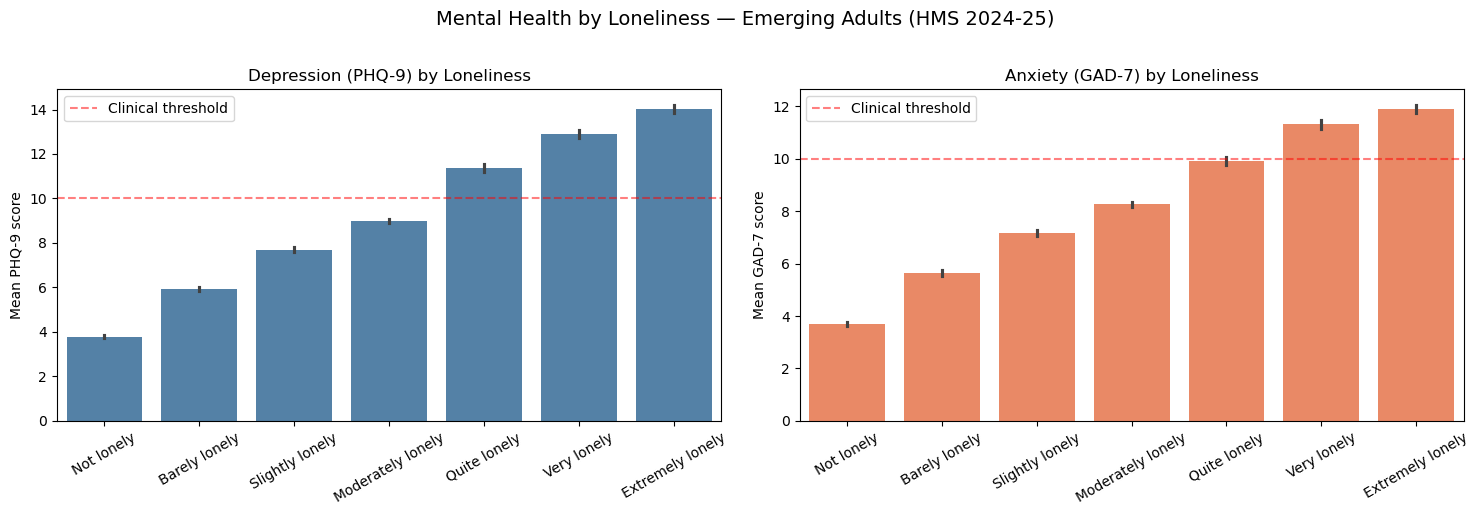

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# depression plot
sns.barplot(data=emerging_adults, x="loneliness_label", y="phq9_total",
            order=label_order, ax=axes[0], color="steelblue", errorbar="ci")
axes[0].axhline(10, color="red", linestyle="--", alpha=0.5, label="Clinical threshold")
axes[0].set_title("Depression (PHQ-9) by Loneliness")
axes[0].set_xlabel("")
axes[0].set_ylabel("Mean PHQ-9 score")
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend()

# anxiety plot
sns.barplot(data=emerging_adults, x="loneliness_label", y="gad7_total",
            order=label_order, ax=axes[1], color="coral", errorbar="ci")
axes[1].axhline(10, color="red", linestyle="--", alpha=0.5, label="Clinical threshold")
axes[1].set_title("Anxiety (GAD-7) by Loneliness")
axes[1].set_xlabel("")
axes[1].set_ylabel("Mean GAD-7 score")
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

plt.suptitle("Mental Health by Loneliness — Emerging Adults (HMS 2024-25)",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../output/mental_health_by_loneliness.png", dpi=150, bbox_inches="tight")
plt.show()